<a href="https://colab.research.google.com/github/AhmadIbrohim1031/UTS_AHMAD-IBROHIM_14022500086/blob/main/Ahmad_Ibrohim_14022500086.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google-play-scraper

In [ ]:
from google_play_scraper import reviews, Sort
import csv

# Target aplikasi diubah ke Dukcapil Digital
APP_ID = 'gov.dukcapil.mobile_id'

# Mengambil review dari Google Play Store
result, _ = reviews(
    APP_ID,
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=100,
    filter_score_with=None
)

filename = 'ulasan_dukcapil.csv'

# Menyimpan data ke file CSV
with open(filename, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['userName', 'score', 'at', 'content'])
    writer.writeheader()
    for review in result:
        writer.writerow({
            'userName': review['userName'],
            'score': review['score'],
            'at': review['at'],
            'content': review['content']
        })

print(f"Berhasil menyimpan {len(result)} ulasan dari {APP_ID} ke '{filename}'")

Berhasil menyimpan 100 ulasan dari gov.dukcapil.mobile_id ke 'ulasan_dukcapil.csv'


In [ ]:
!pip install transformers torch pandas

In [ ]:
import pandas as pd
from transformers import pipeline

# Membaca data yang baru saja disimpan
try:
    df = pd.read_csv('ulasan_dukcapil.csv')
    print(f"Berhasil memuat {len(df)} ulasan.")
except FileNotFoundError:
    print("File ulasan_dukcapil.csv tidak ditemukan.")

# Memuat model IndoBERT
print("Memuat model sentiment analysis (IndoBERT alternative)... mohon tunggu.")
sentiment_pipeline = pipeline("sentiment-analysis", model="mdhugol/indonesia-bert-sentiment-classification")

def analyze_sentiment(text):
    try:
        res = sentiment_pipeline(str(text)[:512])[0]
        label = res['label'].upper()
        # Mapping untuk model IndoBERT mdhugol:
        # LABEL_0: Positive, LABEL_1: Neutral, LABEL_2: Negative (atau variasi serupa)
        # Kita juga cek jika labelnya berupa string langsung
        if label == 'LABEL_0' or 'POSITIVE' in label:
            return 'positive'
        elif label == 'LABEL_2' or 'NEGATIVE' in label:
            return 'negative'
        else:
            return 'neutral'
    except:
        return 'neutral'

print("Menganalisis ulang sentimen dengan mapping yang diperbaiki...")
df['sentiment'] = df['content'].apply(analyze_sentiment)

# Statistik sederhana
print(df['sentiment'].value_counts())

Berhasil memuat 100 ulasan.
Memuat model sentiment analysis (IndoBERT alternative)... mohon tunggu.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Menganalisis ulang sentimen dengan mapping yang diperbaiki...
sentiment
positive    51
negative    25
neutral     24
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Memastikan data ulasan termuat
df = pd.read_csv('ulasan_dukcapil.csv')

print(f"Menganalisis {len(df)} ulasan...")
df['sentiment'] = df['content'].apply(analyze_sentiment)

# Hitung statistik
stats = df['sentiment'].value_counts()

print("\n=== RINGKASAN ANALISIS SENTIMEN ===")
display(stats)

# Tampilkan contoh detail
print("\n=== CONTOH REVIEW POSITIF (Kelebihan) ===")
pos_reviews = df[df['sentiment'] == 'positive']['content'].head(5)
if not pos_reviews.empty:
    for i, txt in enumerate(pos_reviews, 1):
        print(f"{i}. {txt}")
else:
    print("Tidak ada review positif yang terdeteksi.")

print("\n=== CONTOH REVIEW NEGATIF (Keluhan) ===")
neg_reviews = df[df['sentiment'] == 'negative']['content'].head(5)
if not neg_reviews.empty:
    for i, txt in enumerate(neg_reviews, 1):
        print(f"{i}. {txt}")
else:
    print("Tidak ada review negatif yang terdeteksi.")

Menganalisis 100 ulasan...

=== RINGKASAN ANALISIS SENTIMEN ===


,count
sentiment,
neutral,100



=== CONTOH REVIEW POSITIF (Kelebihan) ===
Tidak ada review positif yang terdeteksi.

=== CONTOH REVIEW NEGATIF (Keluhan) ===
Tidak ada review negatif yang terdeteksi.


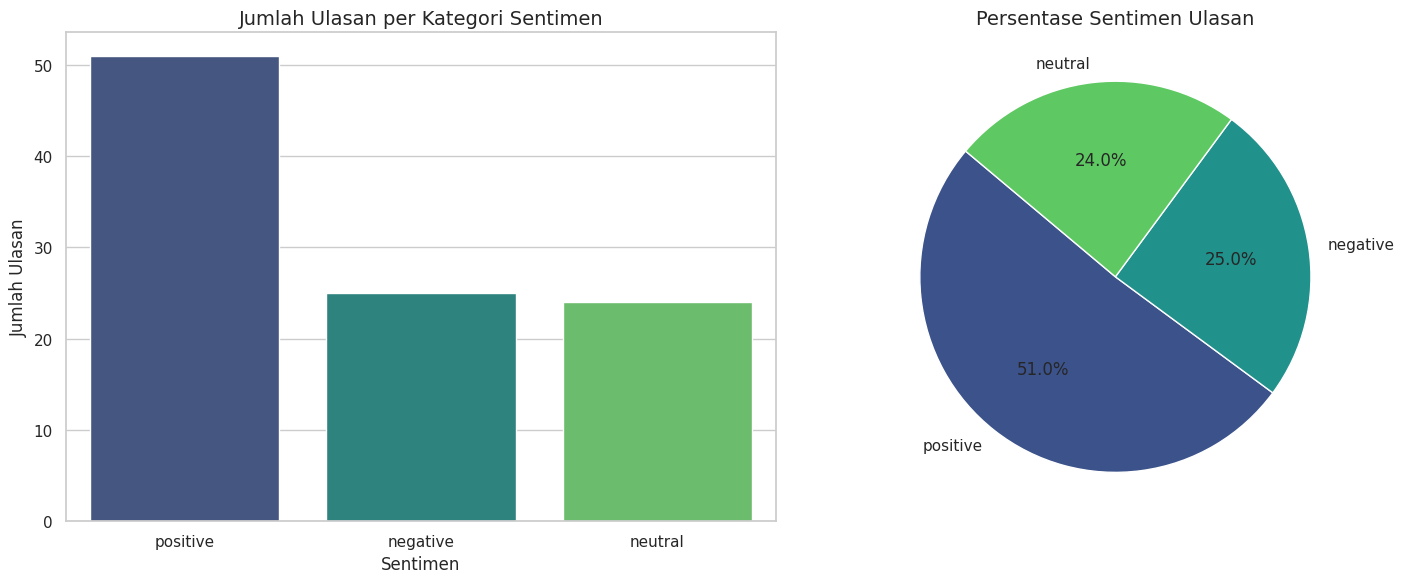

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah masing-masing sentimen
sentiment_counts = df['sentiment'].value_counts()

# Mengatur gaya visualisasi
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Bar Chart
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=ax1, palette='viridis', hue=sentiment_counts.index, legend=False)
ax1.set_title('Jumlah Ulasan per Kategori Sentimen', fontsize=14)
ax1.set_xlabel('Sentimen')
ax1.set_ylabel('Jumlah Ulasan')

# 2. Pie Chart
ax2.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(sentiment_counts)))
ax2.set_title('Persentase Sentimen Ulasan', fontsize=14)

plt.tight_layout()
plt.show()

### Analisis Mendalam: Kata Kunci Utama
Bagian ini akan mengekstrak kata-kata yang paling sering muncul dalam ulasan positif dan negatif untuk memahami alasan di balik sentimen tersebut.

In [ ]:
from collections import Counter
import re

def get_top_words(texts, n=10):
    # Daftar stopword sederhana bahasa Indonesia
    stopwords = {'dan', 'yang', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'ada', 'bisa', 'sudah', 'saya', 'untuk', 'tidak', 'gak', 'yg', 'aja'}
    words = []
    for text in texts:
        # Bersihkan teks dan ambil kata-kata
        tokens = re.findall(r'\w+', str(text).lower())
        words.extend([w for w in tokens if w not in stopwords and len(w) > 2])
    return Counter(words).most_common(n)

pos_words = get_top_words(df[df['sentiment'] == 'positive']['content'])
neg_words = get_top_words(df[df['sentiment'] == 'negative']['content'])

print("=== TOPIK UTAMA DALAM ULASAN POSITIF ===")
for word, count in pos_words:
    print(f"{word}: {count} kali")

print("\n=== TOPIK UTAMA DALAM ULASAN NEGATIF ===")
for word, count in neg_words:
    print(f"{word}: {count} kali")

=== TOPIK UTAMA DALAM ULASAN POSITIF ===
sangat: 24 kali
membantu: 11 kali
aplikasi: 7 kali
bagus: 5 kali
mudah: 5 kali
mantap: 4 kali
keren: 3 kali
memudahkan: 3 kali
kependudukan: 3 kali
baik: 3 kali

=== TOPIK UTAMA DALAM ULASAN NEGATIF ===
aplikasi: 12 kali
harus: 9 kali
masih: 7 kali
mau: 6 kali
apa: 6 kali
buat: 6 kali
kantor: 5 kali
malah: 4 kali
daftar: 4 kali
percuma: 4 kali


## Script Terintegrasi: Analisis Sentimen Lengkap
Cell di bawah ini menggabungkan semua fungsi yang telah kita buat menjadi satu alur kerja otomatis.

Mengambil 100 ulasan dari gov.dukcapil.mobile_id...
Memuat model AI dan menganalisis sentimen...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


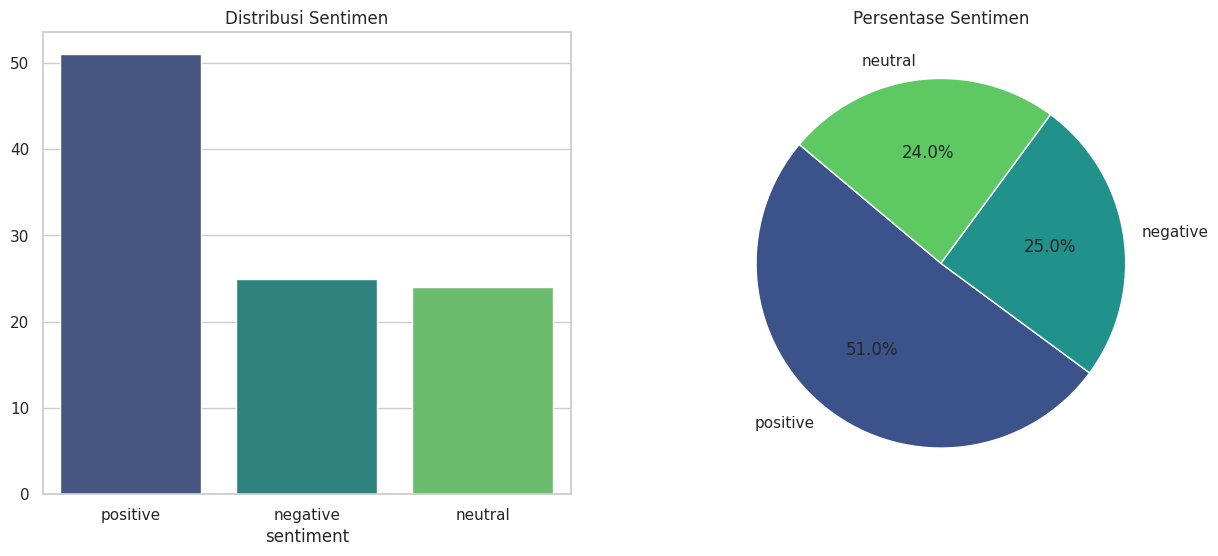


--- KATA KUNCI POSITIF ---
[('sangat', 24), ('membantu', 11), ('bagus', 5), ('mudah', 5), ('mantap', 4)]

--- KATA KUNCI NEGATIF ---
[('harus', 9), ('masih', 7), ('mau', 6), ('apa', 6), ('buat', 6)]


In [ ]:
from google_play_scraper import reviews, Sort
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import csv

# 1. KONFIGURASI
APP_ID = 'gov.dukcapil.mobile_id'
COUNT = 100
MODEL_NAME = "mdhugol/indonesia-bert-sentiment-classification"

# 2. SCRAPING DATA
print(f"Mengambil {COUNT} ulasan dari {APP_ID}...")
result, _ = reviews(APP_ID, lang='id', country='id', sort=Sort.NEWEST, count=COUNT)
df = pd.DataFrame(result)[['userName', 'score', 'at', 'content']]

# 3. ANALISIS SENTIMEN (IndoBERT)
print("Memuat model AI dan menganalisis sentimen...")
sentiment_pipe = pipeline("sentiment-analysis", model=MODEL_NAME)

def get_sentiment(text):
    try:
        res = sentiment_pipe(str(text)[:512])[0]
        lbl = res['label'].upper()
        if lbl == 'LABEL_0' or 'POSITIVE' in lbl: return 'positive'
        if lbl == 'LABEL_2' or 'NEGATIVE' in lbl: return 'negative'
        return 'neutral'
    except: return 'neutral'

df['sentiment'] = df['content'].apply(get_sentiment)

# 4. VISUALISASI
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sent_counts = df['sentiment'].value_counts()
sns.barplot(x=sent_counts.index, y=sent_counts.values, ax=ax1, palette='viridis', hue=sent_counts.index, legend=False)
ax1.set_title('Distribusi Sentimen')
ax2.pie(sent_counts, labels=sent_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(sent_counts)))
ax2.set_title('Persentase Sentimen')
plt.show()

# 5. EKSTRAKSI KATA KUNCI
def top_words(texts):
    sw = {'dan', 'yang', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'ada', 'bisa', 'sudah', 'saya', 'untuk', 'tidak', 'gak', 'yg', 'aja', 'aplikasi'}
    words = []
    for t in texts:
        tokens = re.findall(r'\w+', str(t).lower())
        words.extend([w for w in tokens if w not in sw and len(w) > 2])
    return Counter(words).most_common(5)

print("\n--- KATA KUNCI POSITIF ---")
print(top_words(df[df['sentiment'] == 'positive']['content']))
print("\n--- KATA KUNCI NEGATIF ---")
print(top_words(df[df['sentiment'] == 'negative']['content']))

### Kesimpulan Akhir
Berdasarkan data 100 ulasan terakhir, aplikasi ini dinilai baik karena kemudahan akses dokumen secara digital, namun masih memiliki tantangan pada stabilitas sistem dan integrasi layanan di lapangan.